# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     | Gibrán Leonardo Chávez González  |
| **Fecha**      | 09/03/26  |
| **Expediente** | 757366  | 

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [23]:
import pandas as pd

In [24]:
df = pd.read_csv('Default.csv')

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [25]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [26]:
# Con 10 líneas
df.head(10)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880
5,No,Yes,919.588531,7491.558572
6,No,No,825.513331,24905.226578
7,No,Yes,808.667504,17600.451340
8,No,No,1161.057854,37468.529290
9,No,No,0.000000,29275.268290


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [27]:
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

Existen 4 columnas: default, student, income y balance.

default y student contienen variables categóricas (sí/no) y income y balance contienen variables numéricas.

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [28]:
var_cat = ['default', 'student'] 

In [29]:
df[var_cat] = df[var_cat].astype('category')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   default  10000 non-null  category
 1   student  10000 non-null  category
 2   balance  10000 non-null  float64 
 3   income   10000 non-null  float64 
dtypes: category(2), float64(2)
memory usage: 176.2 KB


Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

In [31]:
import matplotlib.pyplot as plt

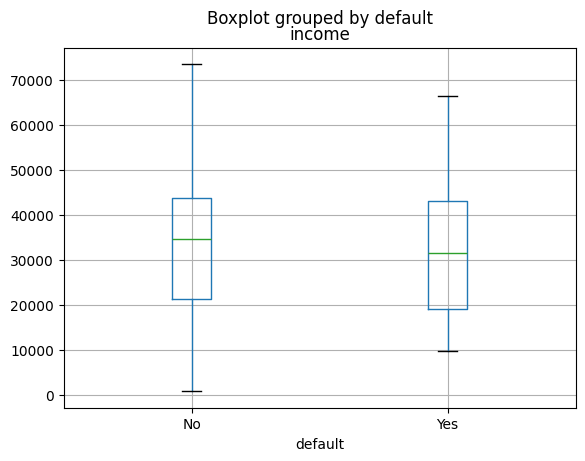

In [32]:
df.boxplot(column='income', by='default')
plt.show()

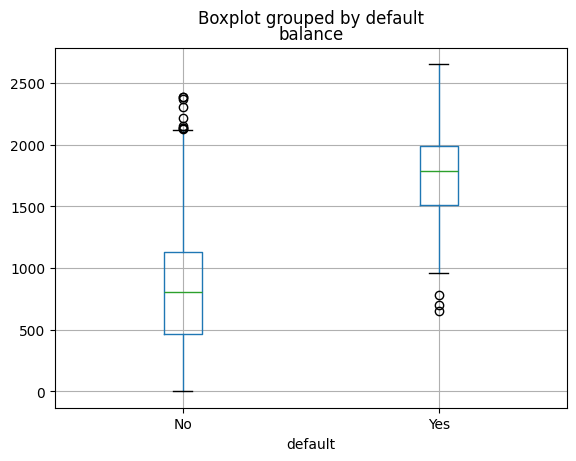

In [33]:
df.boxplot(column='balance', by='default')
plt.show()

In [34]:
import seaborn as sns

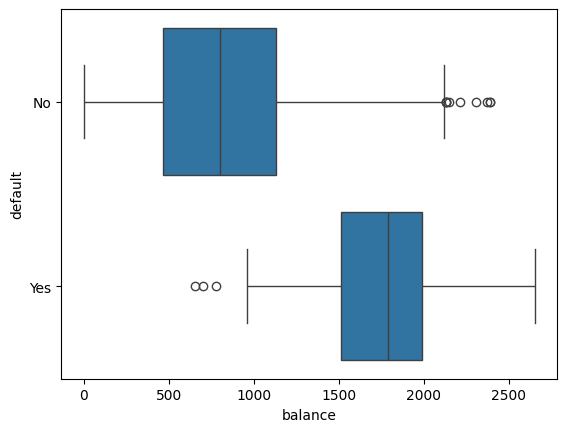

In [35]:
# Otra forma de hacerlo
sns.boxplot(x='balance', y='default', data=df)
plt.show()

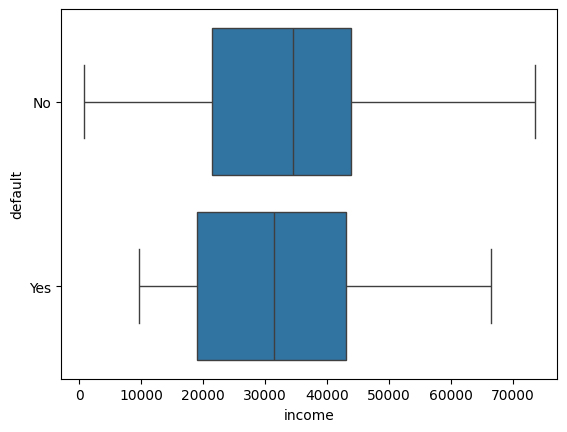

In [36]:
sns.boxplot(x='income', y='default', data=df)
plt.show()

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

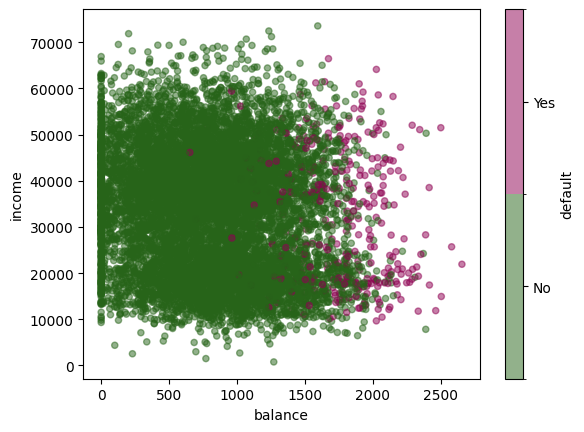

In [37]:
df.plot.scatter(x='balance', y='income', c='default', colormap='PiYG_r', alpha=0.5)
plt.show()

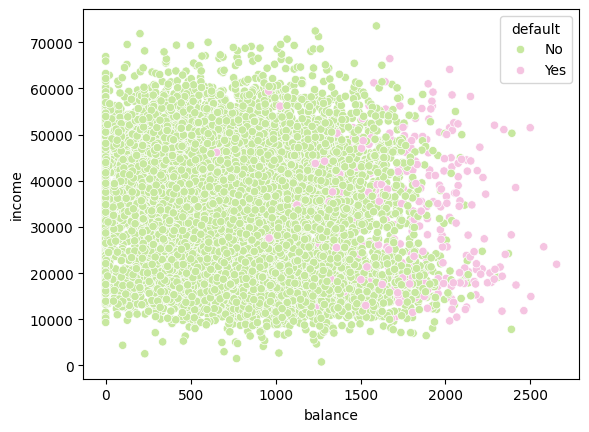

In [38]:
sns.scatterplot(data=df, x='balance', y='income', hue='default', palette='PiYG_r')
plt.show()

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [39]:
y = df['default'] == 'Yes'
y

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: default, Length: 10000, dtype: bool

In [40]:
import numpy as np

In [41]:
X = df['balance']
X

0        729.526495
1        817.180407
2       1073.549164
3        529.250605
4        785.655883
           ...     
9995     711.555020
9996     757.962918
9997     845.411989
9998    1569.009053
9999     200.922183
Name: balance, Length: 10000, dtype: float64

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

In [42]:
y_transformed = y.astype(int)
y_transformed

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: default, Length: 10000, dtype: int64

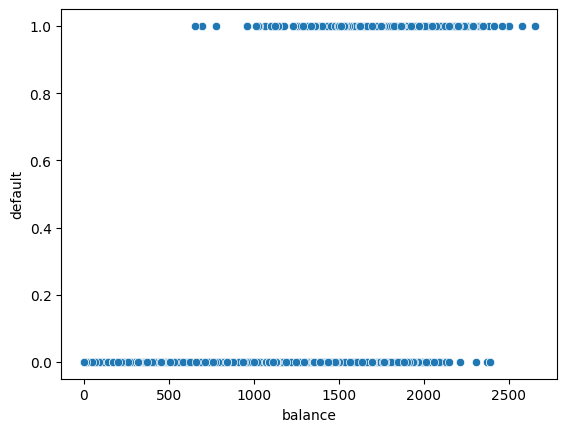

In [43]:
sns.scatterplot(x=X, y=y_transformed)
plt.show()

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [44]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

In [45]:
# Dataframe de X
X = df['balance'].to_frame()
X

,balance
0,729.526495
1,817.180407
2,1073.549164
3,529.250605
4,785.655883
...,...
9995,711.555020
9996,757.962918
9997,845.411989
9998,1569.009053


In [46]:
logistic_model = LogisticRegression()
logistic_model.fit(X, y_transformed)
print(f'b0: {logistic_model.intercept_}, b1: {logistic_model.coef_[0]}')

b0: [-10.65132824], b1: [0.00549892]


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [47]:
y_predicted = logistic_model.predict(X)
y_predicted

array([0, 0, 0, ..., 0, 0, 0], shape=(10000,))

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [48]:
# Calcular p(1 - p) para cada observación
p = logistic_model.predict_proba(X)[:, 1]
p_x_1_menos_p = p * (1 - p)

In [49]:
p_x_1_menos_p

array([1.30397665e-03, 2.10813447e-03, 8.52087844e-03, ...,
       2.46043226e-03, 1.03126823e-01, 7.14425432e-05], shape=(10000,))

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [50]:
V = np.diagflat(p_x_1_menos_p)

In [51]:
V

array([[1.30397665e-03, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.10813447e-03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 8.52087844e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.46043226e-03, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.03126823e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 7.14425432e-05]],
      shape=(10000, 10000))

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [52]:
X = sm.add_constant(X)

In [53]:
cov = np.linalg.inv(X.T @ V @ X)

In [54]:
cov

array([[ 1.30442757e-01, -7.81757265e-05],
       [-7.81757265e-05,  4.85656561e-08]])

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [55]:
se = np.sqrt(np.diag(cov))

In [56]:
se

array([3.61168600e-01, 2.20376169e-04])

Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [57]:
z0 = logistic_model.intercept_ / se[0]
z0

array([-29.49129089])

In [58]:
z1 = logistic_model.coef_[0][0] / se[1]
z1

np.float64(24.952405517879562)

Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [59]:
from scipy.stats import norm

In [60]:
p_value0 = 2 * (1 - norm.cdf(abs(z0)))
p_value0

array([0.])

In [61]:
p_value1 = 2 * (1 - norm.cdf(abs(z1)))
p_value1

np.float64(0.0)

¿Es significativa la relación de los factores con la variable de respuesta?

Sí es significativa, ya que su p-value es de 0.

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [62]:
y2 = df['default'] == 'Yes'
y2 = y2.astype(int)
y2

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: default, Length: 10000, dtype: int64

In [63]:
X2 = (df['student'] == 'Yes').to_frame(); X2 = X2.astype(int); X2

,student
0,0
1,1
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [64]:
logi_r = LogisticRegression(); logi_r.fit(X2, y2)
print(f'b0: {logi_r.intercept_}, b1: {logi_r.coef_[0]}')

b0: [-3.50257249], b1: [0.39620888]


In [65]:
# Paso 1
y2_pred = logi_r.predict(X2)

In [66]:
# Paso 2: p(1-p)
y2_prob = logi_r.predict_proba(X2)[:, 1]
y2_prob_x_1_menos_p = y2_prob * (1 - y2_prob)
y2_prob_x_1_menos_p

array([0.0283842 , 0.04100979, 0.0283842 , ..., 0.0283842 , 0.0283842 ,
       0.04100979], shape=(10000,))

In [67]:
# Paso 3: Matriz diag
V2 = np.diagflat(y2_prob_x_1_menos_p); V2

array([[0.0283842 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.04100979, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.0283842 , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.0283842 , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.0283842 ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.04100979]], shape=(10000, 10000))

In [68]:
# Paso 4: Matriz de covarianza
X2 = sm.add_constant(X2); cov2 = np.linalg.inv(X2.T @ V2 @ X2); cov2

array([[ 0.00499304, -0.00499304],
       [-0.00499304,  0.01327579]])

In [69]:
# Paso 5: Error estándar
se2 = np.sqrt(np.diag(cov2)); se2

array([0.07066143, 0.11522061])

In [70]:
# Estadísticos z
z0_2 = logi_r.intercept_ / se2[0]; z0_2

array([-49.56838058])

In [71]:
z1_2 = logi_r.coef_[0][0] / se2[1]; z1_2

np.float64(3.438697897632719)

In [72]:
# p-values
p_value0_2 = 2 * (1 - norm.cdf(abs(z0_2))); p_value0_2
p_value1_2 = 2 * (1 - norm.cdf(abs(z1_2))); p_value1_2
print(f'p-value b0: {p_value0_2}, p-value b1: {p_value1_2}')

p-value b0: [0.], p-value b1: 0.000584519132502459


Las variables con significativas, ya que sus p-values < 0.05.

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [73]:
y3 = df['default'] == 'Yes'; y3 = y3.astype(int); y3

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: default, Length: 10000, dtype: int64

In [74]:
X3 = df.drop('default', axis=1); X3

,student,balance,income
0,No,729.526495,44361.625074
1,Yes,817.180407,12106.134700
2,No,1073.549164,31767.138950
3,No,529.250605,35704.493940
4,No,785.655883,38463.495880
...,...,...,...
9995,No,711.555020,52992.378910
9996,No,757.962918,19660.721770
9997,No,845.411989,58636.156980
9998,No,1569.009053,36669.112360


In [75]:
X3['student'] = X3['student'] == 'Yes'; X3 = X3.astype(int); X3

,student,balance,income
0,0,729,44361
1,1,817,12106
2,0,1073,31767
3,0,529,35704
4,0,785,38463
...,...,...,...
9995,0,711,52992
9996,0,757,19660
9997,0,845,58636
9998,0,1569,36669


In [76]:
logr_r2 = LogisticRegression(); logr_r2.fit(X3, y3)
print(f'b0: {logr_r2.intercept_}, b1: {logr_r2.coef_[0]}')

b0: [-10.89852636], b1: [-6.12370053e-01  5.73023511e-03  3.96592499e-06]


In [77]:
# 1
y3_pred = logr_r2.predict(X3)

In [78]:
# 2
y3_prob = logr_r2.predict_proba(X3)[:, 1]
y3_prob_x_1_menos_p = y3_prob * (1 - y3_prob)
y3_prob_x_1_menos_p

array([1.43280052e-03, 1.13224693e-03, 9.62366773e-03, ...,
       2.93856205e-03, 1.25034138e-01, 3.36989672e-05], shape=(10000,))

In [79]:
# 3
V3 = np.diagflat(y3_prob_x_1_menos_p); V3

array([[1.43280052e-03, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.13224693e-03, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 9.62366773e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.93856205e-03, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.25034138e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 3.36989672e-05]],
      shape=(10000, 10000))

In [80]:
# 4
X3 = sm.add_constant(X3); cov3 = np.linalg.inv(X3.T @ V3 @ X3); cov3

array([[ 2.43096285e-01, -5.37851909e-02, -8.22548650e-05,
        -2.68607056e-06],
       [-5.37851909e-02,  5.58781794e-02, -9.52247240e-06,
         1.51761324e-06],
       [-8.22548650e-05, -9.52247240e-06,  5.36645235e-08,
        -2.14247590e-11],
       [-2.68607056e-06,  1.51761324e-06, -2.14247590e-11,
         6.73740884e-11]])

In [81]:
# 5
se3 = np.sqrt(np.diag(cov3)); se3

array([4.93047954e-01, 2.36385658e-01, 2.31656046e-04, 8.20817205e-06])

In [82]:
# Estadísticos z
z0_3 = logr_r2.intercept_ / se3[0]; z0_3

array([-22.10439424])

In [83]:
z1_3 = logr_r2.coef_[0][0] / se3[1]; z1_3

np.float64(-2.590555016947281)

In [84]:
z2_3 = logr_r2.coef_[0][1] / se3[2]; z2_3; z2_3

np.float64(24.73596185409523)

In [85]:
z3_3 = logr_r2.coef_[0][2] / se3[3]; z3_3

np.float64(0.48316786789889327)

In [86]:
# p-values
p_value0_3 = 2 * (1 - norm.cdf(abs(z0_3)))
p_value1_3 = 2 * (1 - norm.cdf(abs(z1_3)))
p_value2_3 = 2 * (1 - norm.cdf(abs(z2_3)))
p_value3_3 = 2 * (1 - norm.cdf(abs(z3_3)))
print(f'p-value b0: {p_value0_3}, p-value b1: {p_value1_3}, p-value b2: {p_value2_3}, p-value b3: {p_value3_3}')

p-value b0: [0.], p-value b1: 0.00958213037191169, p-value b2: 0.0, p-value b3: 0.6289765483549818


Las variables $\beta_0$, $\beta_1$ y $\beta_2$ son significativas para este modelo, sin embargo, $\beta_4$ tiene un p-value > 0.05, por lo que no es significativa.

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

### Detector de spam en correos importantes
Si un correo importante se clasifica como spam cuando en realidad no lo es, podrías perder una oferta de trabajo, una fecha límite o información importante. 

### Reconocimiento facial para acceso o vigilancia
Si el sistema identifica erróneamente a una persona inocente como sospechosa, puede causar acusaciones injustas, revisiones innecesarias o problemas legales. 

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

### Diagnóstico médico de una enfermedad grave
Si una persona sí tiene la enfermedad pero la prueba dice que no, podría no recibir tratamiento a tiempo. 

### Detector de fraude bancario
Si una transacción fraudulenta no es detectada y se marca como normal, el cliente puede perder dinero. 

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3